# HW3 Part III — Cloud Radiative Effects

## 7.1 Model Construction

Extending the model to a three-layer atmosphere with sections -

1. Above-cloud ($\tilde\omega = 1$, $g = 0$)
2. Cloud layer ($\tilde\omega = 1$, $g = 0.8$)
3. Below-cloud ($\tilde\omega = 1$, $g = 0$)

With cloud-top at 1 km and cloud thickness of 250 m, assuming the surface at $z = 0$ is perfectly absorbing.

### Estimating cloud optical depth 

For a cloud, the extinction coefficient is

$$\beta_e = \frac{3\,\rho_w}{2\,\rho_l\,r_{\text{eff}}}$$

where $\rho_w$ is the cloud's liquid water content, $\rho_l$ is water density, and $r_{\text{eff}}$ is the effective radius of the drop size distribution. For a vertically homogeneous cloud, $\tau^* = \beta_e\,\Delta z$, which is equivalent to

$$\tau^* = \frac{3\,L}{2\,\rho_l\,r_{\text{eff}}}$$

where $L = \rho_w\,\Delta z$ is the liquid water path.

With $\rho_w = 0.30$ g m$^{-3}$, $\rho_l = 1000$ kg m$^{-3}$, $r_{\text{eff}} = 11\,\mu$m, and $\Delta z = 250$ m (given constants), we therefore can calculate $\tau^* \approx 10$, also computed in the next code cell:

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# cloud parameters
rho_w = 0.30e-3 # liquid water content
rho_l  = 1000.0 # water density
r_eff = 11e-6 # effective radius 
dz_cloud = 250.0 # cloud thickness 

# liquid water path and cloud optical depth
L  = rho_w*dz_cloud
tau_cloud  = 3*L/(2*rho_l*r_eff)
beta_cloud = tau_cloud/dz_cloud
print(f"L = {L*1000:.3f} g/m^2")
print(f"beta_cloud = {beta_cloud:.4f} 1/m")
print(f"tau_cloud  = {tau_cloud:.2f}")

L = 75.000 g/m^2
beta_cloud = 0.0409 1/m
tau_cloud  = 10.23


The following code sets up the parameters for a three layer atmospheric model, inputting a cloud layer:

In [31]:
# heights [m]
z_cloud_top    = 1000.0
z_cloud_bottom = z_cloud_top - dz_cloud
z_TOA          = 20000.0       # TOA

# optical depths
H = 8000.0
tau_total = 0.1
tau_above = tau_total*np.exp(-z_cloud_top/ H)
tau_below = tau_total*(1 - np.exp(-z_cloud_bottom/H))

# atmosphere 
beta_above = tau_above/(z_TOA-z_cloud_top)
beta_below = tau_below/z_cloud_bottom
atmosphere = [(0.0, z_cloud_bottom, beta_below, 1.0, 0.0),    # below cloud 
    (z_cloud_bottom, z_cloud_top, beta_cloud, 1.0, 0.8),    # cloud 
    (z_cloud_top, z_TOA,beta_above, 1.0, 0.0),    # above cloud
]
print(f"tau_above = {tau_above:.4f}")
print(f"tau_cloud = {tau_cloud:.2f}")
print(f"tau_below = {tau_below:.4f}")

tau_above = 0.0882
tau_cloud = 10.23
tau_below = 0.0089


### Create model
The following functions, in order, return the index value of a layer progressing with height, z, sample a scattering path (from Part II), rotates model coordinates at each event (From Part II and Appendix), trace the path of a photon through a multi-layer atmosphere, and run the model to return a list of photon destinations or paths:

In [32]:
rng = np.random.default_rng(42)

def find_layer(z, layers):
    # return the index value of the layer containing height z 
    for i, (z_bot, z_top, _, _, _) in enumerate(layers):
        if z_bot <= z < z_top:
            return i
    return None

def scatter_hg(g):
    # samples a scattering angle from the H-G phase function with asymmetry parameter g
    zeta = rng.random()
    if abs(g) < 1e-6:
        cos_Theta = 2*zeta - 1                     # isotropic limit
    else:
        cos_Theta = (1/(2*g)) * (1 + g**2 -
                    ((1 - g**2) / (1 - g + 2*g*zeta))**2)
    Phi = 2 * np.pi * rng.random()
    return cos_Theta, Phi

def rotate_to_model_coords(k, cos_Theta, Phi):
    # rotate scattered direction from photon frame back to model (xyz) frame
    sin_Theta = np.sqrt(1.0 - cos_Theta**2)
    kp = np.array([sin_Theta*np.cos(Phi),
                   sin_Theta*np.sin(Phi),
                   cos_Theta])
    zp = k
    horiz = np.hypot(k[0], k[1])
    if horiz < 1e-10:
        xp = np.array([1.0, 0.0, 0.0])
    else:
        xp = np.array([-k[1], k[0], 0.0]) / horiz
    yp = np.cross(zp, xp)
    k_new = kp[0]*xp + kp[1]*yp + kp[2]*zp
    return k_new / np.linalg.norm(k_new)
    
def trace_photon(layers, mu_0):
    # trace one photon through a layered atmosphere, return (path, outcome)
    z_TOA = layers[-1][1]
    sin_theta_0 = np.sqrt(1.0 - mu_0**2)
    k   = np.array([sin_theta_0, 0.0, -mu_0])
    pos = np.array([0.0, 0.0, z_TOA - 1e-6])
    path = [pos.copy()]
    n_scatters = 0
    while True:
        tau_step = -np.log(rng.random())
        # propagate until tau_step is complete
        while tau_step > 1e-12:
            idx = find_layer(pos[2], layers)
            if idx is None:
                break
            z_bot, z_top, beta, _, _ = layers[idx]
            # geometric distance to next vertical boundary
            if   k[2] > 0: ds_boundary = (z_top - pos[2]) / k[2]
            elif k[2] < 0: ds_boundary = (z_bot - pos[2]) / k[2]
            else: ds_boundary = np.inf
            dtau_boundary = beta * ds_boundary
            if dtau_boundary >= tau_step:
                # travel the optical path within this layer
                ds  = tau_step / beta
                pos = pos + k * ds
                path.append(pos.copy())
                tau_step = 0
            else:
                # cross into the next layer (cloud or background atmosphere)
                pos = pos + k * ds_boundary
                pos[2] += np.sign(k[2]) * 1e-9
                path.append(pos.copy())
                tau_step -= dtau_boundary
        # exit checks - send to appropriate list
        if pos[2] >= z_TOA:
            return np.array(path), 'reflected'
        if pos[2] <= 0.0:
            return np.array(path), ('direct' if n_scatters == 0 else 'diffuse')
        # interaction at current location
        idx = find_layer(pos[2], layers)
        _, _, _, omega, g = layers[idx]
        if rng.random() >= omega:
            return np.array(path), 'absorbed'
        cos_Theta, Phi = scatter_hg(g)
        k = rotate_to_model_coords(k, cos_Theta, Phi)
        n_scatters += 1 # number scattered count


def monte_carlo_scatter(n_photons, layers, mu_0):
    # run model and return outcome fractions for a layered atmosphere
    counts = dict(reflected=0, direct=0, diffuse=0, absorbed=0)
    for _ in range(n_photons):
        _, outcome = trace_photon(layers, mu_0)
        counts[outcome] += 1
    return {k: v / n_photons for k, v in counts.items()}

### Model output

Run the model with the default cloudy atmosphere at $\mu_0 = 1$ (sun overhead). For a thick non-absorbing cloud with strong forward scattering, we expect a moderately high reflected fraction and a moderately high transmittance to the surface, with essentially zero atmospheric absorption.

## 7.2 Verification

Verify the updated model against two limiting cases:

1. Pure absorption or Beer's Law: Setting $\tilde\omega = 0$ in every layer should eliminate all scattering, so the only photons that reach the surface should travel straight through without interacting. The direct transmittance has to equal $e^{-\tau^*_{\text{TOD}}/\mu_0}$ where $\tau^*_{\text{TOD}} = \tau_{\text{above}} + \tau_{\text{cloud}} + \tau_{\text{below}}$. 

2. Two-stream analytical solution: For a single non-absorbing cloud layer over an absorbing surface, the class notes result from Module 8 gives

$$r = \frac{(1-g)\tau^*}{1 + (1-g)\tau^*}, \qquad t = \frac{1}{1 + (1-g)\tau^*}$$

Running the model on a cloud-only atmosphere (using $\tilde\omega = 1$, $g$, $\tau^*$) should reproduce this. 

In [33]:
# test 1: pure absorption - direct transmittance equals beer's law
absorbing_atmosphere = [(0.0, z_cloud_bottom, beta_below, 0.0, 0.0),
    (z_cloud_bottom, z_cloud_top, beta_cloud, 0.0, 0.0),
    (z_cloud_top, z_TOA, beta_above, 0.0, 0.0)]
mu_0 = 1.0
n_photons = 10000
tau_total = tau_above + tau_cloud + tau_below
expected = np.exp(-tau_total / mu_0)
r1 = monte_carlo_scatter(n_photons, absorbing_atmosphere, mu_0)
print("Test 1: pure absorption (omega = 0 everywhere)")
print(f"  Direct transmittance (MC):    {r1['direct']:.4f}")
print(f"  Direct transmittance (Beer):  {expected:.4f}")
print(f"  Reflected (should be 0):      {r1['reflected']:.4f}")
print(f"  Diffuse (should be 0):        {r1['diffuse']:.4f}")

Test 1: pure absorption (omega = 0 everywhere)
  Direct transmittance (MC):    0.0000
  Direct transmittance (Beer):  0.0000
  Reflected (should be 0):      0.0000
  Diffuse (should be 0):        0.0000


In [34]:
# test 2: cloud-only atmosphere 
cloud_only = [(0.0, dz_cloud, beta_cloud, 1.0, 0.8)]
r2 = monte_carlo_scatter(10000, cloud_only, mu_0=1.0)
r_analytic = (1-0.8)*tau_cloud/(1+(1-0.8)*tau_cloud)
t_analytic = 1/(1+(1-0.8)*tau_cloud)
print("Test 2: cloud-only vs two-stream solution (with omega = 1, g = 0.8)")
print(f"MC reflected: {r2['reflected']:.4f} (analytical r = {r_analytic:.4f})")
print(f"MC transmitted (dir+diff): {r2['direct']+r2['diffuse']:.4f} (analytical t = {t_analytic:.4f})")
print(f"Absorbed (should be 0):{r2['absorbed']:.4f}")
print(f"Sum (should be 1): {r2['reflected']+r2['direct']+r2['diffuse']+r2['absorbed']:.4f}")

Test 2: cloud-only vs two-stream solution (with omega = 1, g = 0.8)
MC reflected: 0.5228 (analytical r = 0.6716)
MC transmitted (dir+diff): 0.4772 (analytical t = 0.3284)
Absorbed (should be 0):0.0000
Sum (should be 1): 1.0000


The verification tests perform as expected, therefore the model can be considered verified.

## 7.3 Questions
### 7.3 a

The shortwave cloud radiative effect (CRE) at the top of the atmosphere (TOA) is defined as the difference in net downward flux between a cloudy and clear condition:

$$\text{CRE} = F_{\text{net, cloudy}}^{\text{TOA}} - F_{\text{net, clear}}^{\text{TOA}} = -S_0\,\mu_0\,(\alpha_{\text{cloudy}} - \alpha_{\text{clear}})$$

with the downward flux at TOA, $S_0\mu_0$, identical in both. A more reflective scene therefore gives a more negative CRE, as the cloud reduces the radiation hitting the planet by sending it back to space.

We can compute the albedo for the a cloudy atmosphere and for a clear atmosphere, with $S_0 = 1361$ W m$^{-2}$ and $\mu_0 = 1$:

In [35]:
# clear-sky
beta_cloud_layer = 0.1*(np.exp(-z_cloud_bottom/H) - np.exp(-z_cloud_top/H))/dz_cloud
clear_atmosphere = [(0.0, z_cloud_bottom, beta_below, 1.0, 0.0),
    (z_cloud_bottom, z_cloud_top, beta_cloud_layer, 1.0, 0.0),
    (z_cloud_top, z_TOA,beta_above,1.0, 0.0)]

S_0  = 1361.0   # solar constant 
mu_0 = 1.0
n_photons = 10000
alpha_cloudy = monte_carlo_scatter(n_photons, atmosphere, mu_0)['reflected']
alpha_clear  = monte_carlo_scatter(n_photons, clear_atmosphere, mu_0)['reflected']
CRE = -S_0 * mu_0 * (alpha_cloudy - alpha_clear)
print(f"alpha_cloudy = {alpha_cloudy:.4f}")
print(f"alpha_clear  = {alpha_clear:.4f}")
print(f"SW CRE at TOA = {CRE:.1f} W/m^2")

alpha_cloudy = 0.5311
alpha_clear  = 0.0431
SW CRE at TOA = -664.2 W/m^2


### 7.3 b

The cloud optical depth depends on the effective radius as

$$\tau^* = \frac{3\,L}{2\,\rho_l\,r_{\text{eff}}}$$

If $L = \rho_w\,\Delta z$ is held fixed (with same total liquid water) but $r_{\text{eff}}$ is decreased. Then, $\tau^*$ increases as $1/r_{\text{eff}}$. Increasing $\tau^*$ raises the cloud albedo $r_{\text{cld}} = (1-g)\tau^*/[1+(1-g)\tau^*]$, so CRE becomes more negative.

Vary $r_{\text{eff}}$ from $5.5\,\mu$m to $22\,\mu$m and plotting CRE - 

d(CRE)/d(r_eff) = 30.13 W/m^2/um


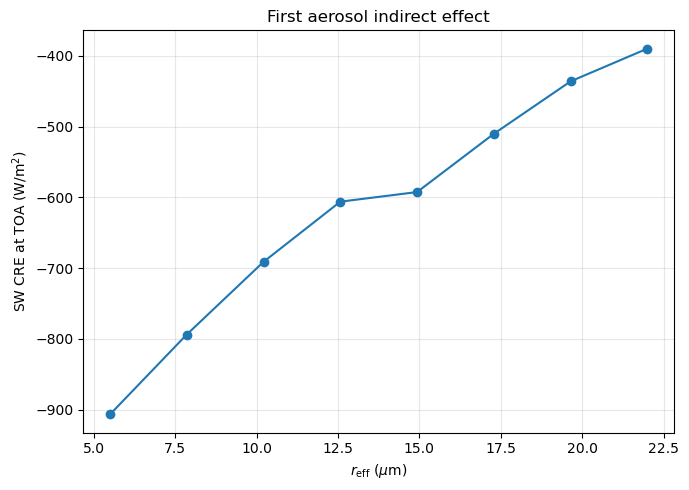

In [36]:
r_eff_array = np.linspace(5.5e-6, 22e-6, 8)
CRE_array   = []

for r_eff_i in r_eff_array:
    # rebuild cloud with new r_eff (fixed L)
    tau_cloud_i  = 3*L / (2*rho_l*r_eff_i)
    beta_cloud_i = tau_cloud_i / dz_cloud
    atm_i = [(0.0, z_cloud_bottom, beta_below, 1.0, 0.0),
        (z_cloud_bottom, z_cloud_top, beta_cloud_i, 1.0, 0.8),
        (z_cloud_top, z_TOA,beta_above,   1.0, 0.0)]
    a_cloudy = monte_carlo_scatter(2000, atm_i, mu_0)['reflected']
    CRE_array.append(-S_0*mu_0*(a_cloudy - alpha_clear))
CRE_array = np.array(CRE_array)
r_eff_um  = r_eff_array * 1e6

# slope of CRE vs r_eff (do a fit)
slope, intercept = np.polyfit(r_eff_um, CRE_array, 1)
print(f"d(CRE)/d(r_eff) = {slope:.2f} W/m^2/um")

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(r_eff_um, CRE_array, 'o-')
ax.set_xlabel(r'$r_{\rm eff}$ ($\mu$m)')
ax.set_ylabel('SW CRE at TOA (W/m$^2$)')
ax.set_title('First aerosol indirect effect')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Result: 
CRE becomes less negative as $r_{\text{eff}}$ increases, with a positive slope of 27.41 W m$^{-2}$ $\mu$m$^{-1}$. Smaller droplets therefore give optically thicker clouds and a more reflective scene, even with the same total water content. 

### 7.3 c

Question: How does CRE vary with solar zenith angle?

Hypothesis: The CRE should depend on $\mu_0$. The down flux at TOA scales as $S_0\mu_0$, so the magnitude of reflection goes to zero at a low sun. However, photons entering at slanted angles should travel through more cloud, so the cloud should also become more reflective. The net result to be non-monotonic, with small magnitude changes at $\mu_0 \to 0$ (no sun), small changes at $\mu_0 = 1$ (least slant), and maximum effects somewhere in between.

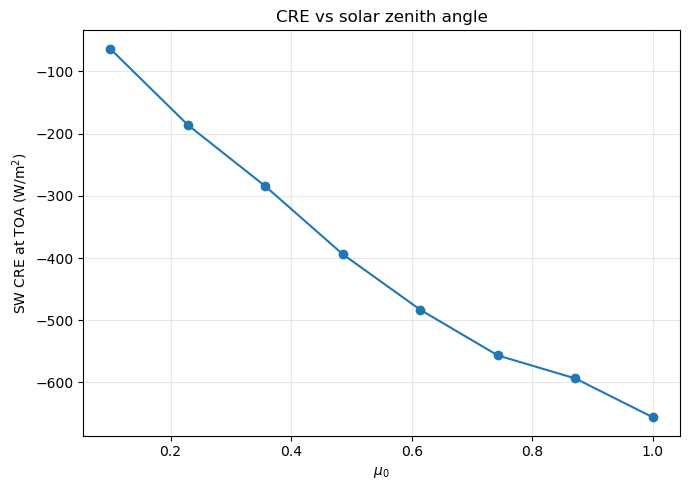

In [39]:
mu_0_array = np.linspace(0.1, 1.0, 8)
CRE_mu0 = []
for m in mu_0_array:
    a_cloudy = monte_carlo_scatter(2000, atmosphere, m)['reflected']
    a_clear  = monte_carlo_scatter(2000, clear_atmosphere, m)['reflected']
    CRE_mu0.append(-S_0*m*(a_cloudy - a_clear))

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(mu_0_array, CRE_mu0, 'o-')
ax.set_xlabel(r'$\mu_0$')
ax.set_ylabel('SW CRE at TOA (W/m$^2$)')
ax.set_title('CRE vs solar zenith angle')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Result
The hypothesis was only partially correct. CRE scales nearly linearly with $\mu_0$, going from about $-70$ W m$^{-2}$ at $\mu_0 = 0.07$ to roughly $-630$ W m$^{-2}$ at $\mu_0 = 1$. The slant-path effect, where I stated a more reflective cloud at a lower sun, is more negligible than expected. To explain this, since the cloud is already optically thick ($\tau^* \approx 10$), its albedo is close to its asymptotic value $r_{\text{cld}} = (1-g)\tau^*/[1+(1-g)\tau^*]$ regardless of path angle, so lengthening the path doesn't add much more reflectance. The $\mu_0$ factor in $S_0\mu_0$ dominates, giving linear behavior. So, for thick clouds the SW CRE is controlled by sunlight flux, rather than slant angles.

## AI Contribution

I used Claude and VSCode AI tools. AI assistance was used for cross-checking derivation of the cloud optical depth ($\rho_w$, $\rho_l$, $r_{\text{eff}}$, $L$), structuring and updating the three-layer atmosphere model (trace_photon function) as well as modifying the photon tracer to handle layer boundary crossings, and writing the CRE calculation steps. It also verified the entire assignment for any inaccurate statements.

Check: AI explained that CRE becomes more negative as $r_{\text{eff}}$ decreases. I verified this myself by using the model to compute $\tau^* = 3L/(2\rho_l r_{\text{eff}})$ at $r_{\text{eff}} = 5.5\,\mu$m and $11\,\mu$m, confirming that halving the radius doubles the optical depth (and therefore makes the CRE more negative).